In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import eigh as scipy_eigh
from scipy.sparse.linalg import LinearOperator, eigsh

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

FIGDIR = "figureAKLT"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIGDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved: {path}")

In [2]:
def spin_half_ops(dtype=np.complex128):
    I = np.eye(2, dtype=dtype)
    Sp = np.array([[0, 1],
                   [0, 0]], dtype=dtype)
    Sm = np.array([[0, 0],
                   [1, 0]], dtype=dtype)
    Sz = 0.5 * np.array([[1, 0],
                         [0, -1]], dtype=dtype)
    return I, Sp, Sm, Sz


def spin_one_ops(dtype=np.complex128):
    I = np.eye(3, dtype=dtype)
    Sp = np.sqrt(2) * np.array([[0, 1, 0],
                                [0, 0, 1],
                                [0, 0, 0]], dtype=dtype)
    Sm = np.sqrt(2) * np.array([[0, 0, 0],
                                [1, 0, 0],
                                [0, 1, 0]], dtype=dtype)
    Sz = np.array([[1, 0, 0],
                   [0, 0, 0],
                   [0, 0, -1]], dtype=dtype)
    return I, Sp, Sm, Sz

In [3]:
def heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.0, dtype=np.complex128):
    I, Sp, Sm, Sz = spin_half_ops(dtype=dtype)
    d = 2
    chi = 5

    Wbulk = np.zeros((chi, chi, d, d), dtype=dtype)
    Wbulk[0, 0] = I
    Wbulk[1, 0] = Sp
    Wbulk[2, 0] = Sm
    Wbulk[3, 0] = Sz
    Wbulk[4, 0] = -h * Sz
    Wbulk[4, 1] = (J / 2.0) * Sm
    Wbulk[4, 2] = (J / 2.0) * Sp
    Wbulk[4, 3] = Jz * Sz
    Wbulk[4, 4] = I

    Wleft = np.zeros((1, chi, d, d), dtype=dtype)
    Wleft[0, 0] = -h * Sz
    Wleft[0, 1] = (J / 2.0) * Sm
    Wleft[0, 2] = (J / 2.0) * Sp
    Wleft[0, 3] = Jz * Sz
    Wleft[0, 4] = I

    Wright = np.zeros((chi, 1, d, d), dtype=dtype)
    Wright[0, 0] = I
    Wright[1, 0] = Sp
    Wright[2, 0] = Sm
    Wright[3, 0] = Sz
    Wright[4, 0] = -h * Sz

    mpo = [None] * L
    mpo[0] = Wleft
    for i in range(1, L - 1):
        mpo[i] = Wbulk.copy()
    mpo[L - 1] = Wright
    return mpo


def aklt_mpo(L, dtype=np.complex128):
    I, Sp, Sm, Sz = spin_one_ops(dtype=dtype)
    d = 3
    chi = 14

    O = [Sp / np.sqrt(2.0), Sm / np.sqrt(2.0), Sz]
    Obar = [Sm / np.sqrt(2.0), Sp / np.sqrt(2.0), Sz]

    O2 = []
    Obar2 = []
    for a in range(3):
        for b in range(3):
            O2.append(O[a] @ O[b])
            Obar2.append(Obar[a] @ Obar[b])

    Wbulk = np.zeros((chi, chi, d, d), dtype=dtype)

    Wbulk[0, 0] = I
    for a in range(3):
        Wbulk[0, 1 + a] = O[a]
    for ab in range(9):
        Wbulk[0, 4 + ab] = (1.0 / 3.0) * O2[ab]

    for a in range(3):
        Wbulk[1 + a, 13] = Obar[a]
    for ab in range(9):
        Wbulk[4 + ab, 13] = Obar2[ab]

    Wbulk[13, 13] = I

    Wleft = np.zeros((1, chi, d, d), dtype=dtype)
    Wleft[0, 0] = I
    for a in range(3):
        Wleft[0, 1 + a] = O[a]
    for ab in range(9):
        Wleft[0, 4 + ab] = (1.0 / 3.0) * O2[ab]

    Wright = np.zeros((chi, 1, d, d), dtype=dtype)
    for a in range(3):
        Wright[1 + a, 0] = Obar[a]
    for ab in range(9):
        Wright[4 + ab, 0] = Obar2[ab]
    Wright[13, 0] = I

    mpo = [None] * L
    mpo[0] = Wleft
    for i in range(1, L - 1):
        mpo[i] = Wbulk.copy()
    mpo[L - 1] = Wright
    return mpo

In [4]:
def kron_all(ops):
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out


def onsite_op(L, i, op, d):
    I = np.eye(d, dtype=np.complex128)
    ops = [I] * L
    ops[i] = op
    return kron_all(ops)


def bond_op(L, i, op_i, op_j, d):
    I = np.eye(d, dtype=np.complex128)
    ops = [I] * L
    ops[i] = op_i
    ops[i + 1] = op_j
    return kron_all(ops)


def dense_heisenberg(L, J=1.0, Jz=1.0, h=0.0):
    I, Sp, Sm, Sz = spin_half_ops()
    d = 2
    H = np.zeros((d**L, d**L), dtype=np.complex128)

    for i in range(L - 1):
        H += (J / 2.0) * bond_op(L, i, Sp, Sm, d)
        H += (J / 2.0) * bond_op(L, i, Sm, Sp, d)
        H += Jz * bond_op(L, i, Sz, Sz, d)

    for i in range(L):
        H += -h * onsite_op(L, i, Sz, d)

    return H


def dense_aklt(L):
    I, Sp, Sm, Sz = spin_one_ops()
    d = 3
    H = np.zeros((d**L, d**L), dtype=np.complex128)

    for i in range(L - 1):
        X = (
            0.5 * bond_op(L, i, Sp, Sm, d)
            + 0.5 * bond_op(L, i, Sm, Sp, d)
            + bond_op(L, i, Sz, Sz, d)
        )
        H += X + (1.0 / 3.0) * (X @ X)

    return H

In [5]:
def mpo_to_dense(mpo):
    L = len(mpo)
    cur = mpo[0][0]  # shape (chi, d, d)
    cur_ops = [cur[b] for b in range(cur.shape[0])]

    for i in range(1, L):
        W = mpo[i]
        chiL, chiR, d, _ = W.shape
        new_ops = [
            np.zeros((cur_ops[0].shape[0] * d, cur_ops[0].shape[1] * d), dtype=np.complex128)
            for _ in range(chiR)
        ]

        for bl in range(chiL):
            for br in range(chiR):
                if np.linalg.norm(W[bl, br]) == 0:
                    continue
                new_ops[br] += np.kron(cur_ops[bl], W[bl, br])

        cur_ops = new_ops

    assert len(cur_ops) == 1
    return cur_ops[0]


def test_mpo_heisenberg():
    for L in [2, 3, 4]:
        H1 = mpo_to_dense(heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.2))
        H2 = dense_heisenberg(L, J=1.0, Jz=1.0, h=0.2)
        err = np.max(np.abs(H1 - H2))
        print(f"Heisenberg MPO test L={L}: max|diff| = {err:.3e}")


def test_mpo_aklt():
    for L in [2, 3, 4]:
        H1 = mpo_to_dense(aklt_mpo(L))
        H2 = dense_aklt(L)
        err = np.max(np.abs(H1 - H2))
        print(f"AKLT MPO test L={L}: max|diff| = {err:.3e}")

In [6]:
def random_mps(L, d, Dmax, seed=1234, dtype=np.complex128):
    rng = np.random.default_rng(seed)

    dims = [1]
    for i in range(1, L):
        dims.append(min(Dmax, d ** min(i, L - i)))
    dims.append(1)

    mps = []
    for i in range(L):
        Dl, Dr = dims[i], dims[i + 1]
        A = rng.normal(size=(Dl, d, Dr)) + 1j * rng.normal(size=(Dl, d, Dr))
        mps.append(A.astype(dtype))
    return mps


def mps_to_state(mps):
    psi = mps[0][0]  # (d, D1)
    for i in range(1, len(mps)):
        psi = np.einsum('...a,asb->...sb', psi, mps[i], optimize=True)
    return psi.reshape(-1, order='C')


def normalize_mps_by_state(mps):
    psi = mps_to_state(mps)
    nrm = np.sqrt(np.vdot(psi, psi).real)
    mps[0] = mps[0] / nrm
    return mps

In [7]:
def right_canonicalize(mps):
    mps = [A.copy() for A in mps]
    L = len(mps)

    for i in range(L - 1, 0, -1):
        A = mps[i]
        Dl, d, Dr = A.shape
        M = A.reshape(Dl, d * Dr, order='C')
        Q, R = np.linalg.qr(M.conj().T, mode='reduced')
        B = Q.conj().T.reshape((-1, d, Dr), order='C')
        mps[i] = B
        Rd = R.conj().T
        mps[i - 1] = np.einsum('xsa,ab->xsb', mps[i - 1], Rd, optimize=True)

    return mps


def left_canonicalize(mps):
    mps = [A.copy() for A in mps]
    L = len(mps)

    for i in range(L - 1):
        A = mps[i]
        Dl, d, Dr = A.shape
        M = A.reshape(Dl * d, Dr, order='C')
        Q, R = np.linalg.qr(M, mode='reduced')
        k = Q.shape[1]
        mps[i] = Q.reshape(Dl, d, k, order='C')
        mps[i + 1] = np.einsum('ab,bsd->asd', R, mps[i + 1], optimize=True)

    return mps

In [8]:
def form_theta(A, B):
    return np.einsum('asm,mtr->astr', A, B, optimize=True)


def split_theta_left_to_right(theta, Dmax, svd_cutoff=1e-12):
    Dl, d1, d2, Dr = theta.shape
    M = theta.reshape((Dl * d1, d2 * Dr), order='C')

    U, S, Vh = np.linalg.svd(M, full_matrices=False)

    keep = np.sum(S > svd_cutoff)
    keep = max(1, min(Dmax, keep, len(S)))

    disc_weight = np.sum(S[keep:]**2).real

    U = U[:, :keep]
    S = S[:keep]
    Vh = Vh[:keep, :]

    A = U.reshape((Dl, d1, keep), order='C')
    B = (np.diag(S) @ Vh).reshape((keep, d2, Dr), order='C')
    return A, B, S, disc_weight


def split_theta_right_to_left(theta, Dmax, svd_cutoff=1e-12):
    Dl, d1, d2, Dr = theta.shape
    M = theta.reshape((Dl * d1, d2 * Dr), order='C')

    U, S, Vh = np.linalg.svd(M, full_matrices=False)

    keep = np.sum(S > svd_cutoff)
    keep = max(1, min(Dmax, keep, len(S)))

    disc_weight = np.sum(S[keep:]**2).real

    U = U[:, :keep]
    S = S[:keep]
    Vh = Vh[:keep, :]

    A = (U @ np.diag(S)).reshape((Dl, d1, keep), order='C')
    B = Vh.reshape((keep, d2, Dr), order='C')
    return A, B, S, disc_weight

In [9]:
def left_basis_map(mps, i):
    """
    Returns UL with shape (dim_left, Dl)
    for bond (i-1 | i).
    """
    if i == 0:
        return np.array([[1.0]], dtype=np.complex128)

    X = mps[0][0]  # (d, D1)
    for k in range(1, i):
        X = np.einsum('pa,asb->psb', X, mps[k], optimize=True)
        X = X.reshape((-1, X.shape[-1]), order='C')
    return X


def right_basis_map(mps, i):
    """
    For bond (i, i+1), returns UR with shape (Dr, dim_right),
    where Dr is the right bond dimension of site i+1.
    """
    L = len(mps)
    if i == L - 2:
        return np.array([[1.0]], dtype=np.complex128)

    A = mps[i + 2]
    X = A
    for k in range(i + 3, L):
        X = np.einsum('asd,dtu->astu', X, mps[k], optimize=True)
        X = X.reshape((X.shape[0], -1, X.shape[-1]), order='C')
    return X[:, :, 0]

In [10]:
def dense_projected_two_site_heff_from_full(Hfull, mps, i, d):
    """
    Exact projected two-site effective Hamiltonian for bond (i, i+1).
    Small systems only.
    """
    UL = left_basis_map(mps, i)   # (dimL, Dl)
    UR = right_basis_map(mps, i)  # (Dr, dimR)

    Dl = UL.shape[1]
    Dr = UR.shape[0]
    dimL = UL.shape[0]
    dimR = UR.shape[1]

    Nloc = Dl * d * d * Dr
    Dim = dimL * d * d * dimR
    P = np.zeros((Dim, Nloc), dtype=np.complex128)

    col = 0
    for a in range(Dl):
        for s in range(d):
            for t in range(d):
                for c in range(Dr):
                    mid = np.zeros(d * d, dtype=np.complex128)
                    mid[s * d + t] = 1.0
                    vec = np.kron(UL[:, a], np.kron(mid, UR[c, :]))
                    P[:, col] = vec
                    col += 1

    Heff = P.conj().T @ Hfull @ P
    return Heff

In [11]:
def local_theta_to_full_state(theta, mps, i, d):
    """
    Embed theta[a,s,t,c] into the full Hilbert space.
    """
    UL = left_basis_map(mps, i)    # (dimL, Dl)
    UR = right_basis_map(mps, i)   # (Dr, dimR)

    Dl, d1, d2, Dr = theta.shape
    assert d1 == d and d2 == d

    dimL = UL.shape[0]
    dimR = UR.shape[1]

    psi = np.zeros(dimL * d * d * dimR, dtype=np.complex128)

    for a in range(Dl):
        for s in range(d):
            for t in range(d):
                for c in range(Dr):
                    amp = theta[a, s, t, c]
                    if abs(amp) < 1e-15:
                        continue
                    mid = np.zeros(d * d, dtype=np.complex128)
                    mid[s * d + t] = 1.0
                    psi += amp * np.kron(UL[:, a], np.kron(mid, UR[c, :]))

    return psi


def full_state_to_local_theta(psi_full, mps, i, d):
    """
    Project full Hilbert-space vector back to theta[a,s,t,c].
    """
    UL = left_basis_map(mps, i)    # (dimL, Dl)
    UR = right_basis_map(mps, i)   # (Dr, dimR)

    Dl = UL.shape[1]
    Dr = UR.shape[0]
    dimL = UL.shape[0]
    dimR = UR.shape[1]

    psi4 = psi_full.reshape((dimL, d, d, dimR), order='C')
    theta = np.zeros((Dl, d, d, Dr), dtype=np.complex128)

    for a in range(Dl):
        for c in range(Dr):
            theta[a, :, :, c] = np.einsum(
                'L,LstR,R->st',
                UL[:, a].conj(),
                psi4,
                UR[c, :].conj(),
                optimize=True
            )

    return theta


def heff_two_site_projected_matvec(v, Hfull, mps, i, d):
    """
    Matrix-free exact local action: v -> P^\dagger H P v
    """
    Dl = mps[i].shape[0]
    Dr = mps[i + 1].shape[2]

    theta = v.reshape((Dl, d, d, Dr), order='C')
    psi_full = local_theta_to_full_state(theta, mps, i, d)
    Hpsi = Hfull @ psi_full
    theta_out = full_state_to_local_theta(Hpsi, mps, i, d)
    return theta_out.reshape(-1, order='C')

In [12]:
def two_site_dmrg_dense_reference(
    Hfull,
    mpo,
    d,
    Dmax=32,
    nsweeps=6,
    svd_cutoff=1e-12,
    seed=1234,
    verbose=True,
):
    """
    Reference two-site DMRG using exact dense projected local Hamiltonians.
    """
    L = len(mpo)

    mps = random_mps(L, d=d, Dmax=min(Dmax, 4), seed=seed)
    mps = normalize_mps_by_state(mps)
    mps = right_canonicalize(mps)

    sweep_energies = []
    sweep_discards = []

    for sweep in range(nsweeps):
        discards_this_sweep = []

        # Left-to-right
        for i in range(L - 1):
            theta0 = form_theta(mps[i], mps[i + 1])
            Dl, d1, d2, Dr = theta0.shape

            Heff = dense_projected_two_site_heff_from_full(Hfull, mps, i, d)
            Heff = 0.5 * (Heff + Heff.conj().T)

            vals, vecs = scipy_eigh(Heff)
            theta = vecs[:, 0].reshape((Dl, d1, d2, Dr), order='C')

            Anew, Bnew, S, disc = split_theta_left_to_right(theta, Dmax, svd_cutoff)
            mps[i] = Anew
            mps[i + 1] = Bnew
            discards_this_sweep.append(disc)

        mps = left_canonicalize(mps)
        mps = normalize_mps_by_state(mps)

        # Right-to-left
        for i in range(L - 2, -1, -1):
            theta0 = form_theta(mps[i], mps[i + 1])
            Dl, d1, d2, Dr = theta0.shape

            Heff = dense_projected_two_site_heff_from_full(Hfull, mps, i, d)
            Heff = 0.5 * (Heff + Heff.conj().T)

            vals, vecs = scipy_eigh(Heff)
            theta = vecs[:, 0].reshape((Dl, d1, d2, Dr), order='C')

            Anew, Bnew, S, disc = split_theta_right_to_left(theta, Dmax, svd_cutoff)
            mps[i] = Anew
            mps[i + 1] = Bnew
            discards_this_sweep.append(disc)

        mps = right_canonicalize(mps)
        mps = normalize_mps_by_state(mps)

        psi = mps_to_state(mps)
        E = (np.vdot(psi, Hfull @ psi) / np.vdot(psi, psi)).real
        max_disc = max(discards_this_sweep) if discards_this_sweep else 0.0

        sweep_energies.append(E)
        sweep_discards.append(max_disc)

        if verbose:
            print(f"Sweep {sweep+1:2d}: E = {E:.12f}, max discarded weight = {max_disc:.3e}")

    return mps, np.array(sweep_energies), np.array(sweep_discards)

In [13]:
def two_site_dmrg_matrix_free_projected(
    Hfull,
    mpo,
    d,
    Dmax=32,
    nsweeps=6,
    lanczos_tol=1e-10,
    lanczos_maxiter=None,
    svd_cutoff=1e-12,
    seed=1234,
    verbose=True,
):
    """
    Correct matrix-free two-site DMRG using the exact projected action
    v -> P^\dagger H P v, without assembling the local Heff matrix.
    """
    L = len(mpo)

    mps = random_mps(L, d=d, Dmax=min(Dmax, 4), seed=seed)
    mps = normalize_mps_by_state(mps)
    mps = right_canonicalize(mps)

    sweep_energies = []
    sweep_discards = []

    for sweep in range(nsweeps):
        discards_this_sweep = []

        # Left-to-right
        for i in range(L - 1):
            theta0 = form_theta(mps[i], mps[i + 1])
            Dl, d1, d2, Dr = theta0.shape
            Nloc = Dl * d1 * d2 * Dr

            Heff = LinearOperator(
                shape=(Nloc, Nloc),
                matvec=lambda v, Hfull=Hfull, mps=mps, i=i, d=d:
                    heff_two_site_projected_matvec(v, Hfull, mps, i, d),
                dtype=np.complex128
            )

            v0 = theta0.reshape(-1, order='C')
            vals, vecs = eigsh(
                Heff, k=1, which='SA',
                v0=v0, tol=lanczos_tol, maxiter=lanczos_maxiter
            )
            theta = vecs[:, 0].reshape((Dl, d, d, Dr), order='C')

            Anew, Bnew, S, disc = split_theta_left_to_right(theta, Dmax, svd_cutoff)
            mps[i] = Anew
            mps[i + 1] = Bnew
            discards_this_sweep.append(disc)

        mps = left_canonicalize(mps)
        mps = normalize_mps_by_state(mps)

        # Right-to-left
        for i in range(L - 2, -1, -1):
            theta0 = form_theta(mps[i], mps[i + 1])
            Dl, d1, d2, Dr = theta0.shape
            Nloc = Dl * d1 * d2 * Dr

            Heff = LinearOperator(
                shape=(Nloc, Nloc),
                matvec=lambda v, Hfull=Hfull, mps=mps, i=i, d=d:
                    heff_two_site_projected_matvec(v, Hfull, mps, i, d),
                dtype=np.complex128
            )

            v0 = theta0.reshape(-1, order='C')
            vals, vecs = eigsh(
                Heff, k=1, which='SA',
                v0=v0, tol=lanczos_tol, maxiter=lanczos_maxiter
            )
            theta = vecs[:, 0].reshape((Dl, d, d, Dr), order='C')

            Anew, Bnew, S, disc = split_theta_right_to_left(theta, Dmax, svd_cutoff)
            mps[i] = Anew
            mps[i + 1] = Bnew
            discards_this_sweep.append(disc)

        mps = right_canonicalize(mps)
        mps = normalize_mps_by_state(mps)

        psi = mps_to_state(mps)
        E = (np.vdot(psi, Hfull @ psi) / np.vdot(psi, psi)).real
        max_disc = max(discards_this_sweep) if discards_this_sweep else 0.0

        sweep_energies.append(E)
        sweep_discards.append(max_disc)

        if verbose:
            print(f"Sweep {sweep+1:2d}: E = {E:.12f}, max discarded weight = {max_disc:.3e}")

    return mps, np.array(sweep_energies), np.array(sweep_discards)

In [14]:
test_mpo_heisenberg()
test_mpo_aklt()

Heisenberg MPO test L=2: max|diff| = 0.000e+00
Heisenberg MPO test L=3: max|diff| = 5.551e-17
Heisenberg MPO test L=4: max|diff| = 2.220e-16
AKLT MPO test L=2: max|diff| = 3.331e-16
AKLT MPO test L=3: max|diff| = 6.661e-16
AKLT MPO test L=4: max|diff| = 8.882e-16


In [15]:
Lh = 8
Hh = dense_heisenberg(Lh, J=1.0, Jz=1.0, h=0.0)
mpo_h = heisenberg_mpo(Lh, J=1.0, Jz=1.0, h=0.0)

mps_h_ref, Ehist_h_ref, disc_h_ref = two_site_dmrg_dense_reference(
    Hfull=Hh,
    mpo=mpo_h,
    d=2,
    Dmax=32,
    nsweeps=6,
    svd_cutoff=1e-12,
    seed=10,
    verbose=True,
)

Eexact_h = np.linalg.eigvalsh(Hh)[0].real
psi_h_ref = mps_to_state(mps_h_ref)
Edmrg_h_ref = (np.vdot(psi_h_ref, Hh @ psi_h_ref) / np.vdot(psi_h_ref, psi_h_ref)).real

print("\nHeisenberg dense-reference DMRG")
print("DMRG energy :", Edmrg_h_ref)
print("Exact energy:", Eexact_h)
print("Abs error   :", abs(Edmrg_h_ref - Eexact_h))

Sweep  1: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  2: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  3: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  4: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  5: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  6: E = -3.374932598688, max discarded weight = 0.000e+00

Heisenberg dense-reference DMRG
DMRG energy : -3.374932598687891
Exact energy: -3.374932598687897
Abs error   : 5.773159728050814e-15


In [16]:
mps_h_mf, Ehist_h_mf, disc_h_mf = two_site_dmrg_matrix_free_projected(
    Hfull=Hh,
    mpo=mpo_h,
    d=2,
    Dmax=32,
    nsweeps=6,
    lanczos_tol=1e-10,
    svd_cutoff=1e-12,
    seed=10,
    verbose=True,
)

psi_h_mf = mps_to_state(mps_h_mf)
Edmrg_h_mf = (np.vdot(psi_h_mf, Hh @ psi_h_mf) / np.vdot(psi_h_mf, psi_h_mf)).real

print("\nHeisenberg matrix-free projected DMRG")
print("DMRG energy :", Edmrg_h_mf)
print("Exact energy:", Eexact_h)
print("Abs error   :", abs(Edmrg_h_mf - Eexact_h))

Sweep  1: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  2: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  3: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  4: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  5: E = -3.374932598688, max discarded weight = 0.000e+00
Sweep  6: E = -3.374932598688, max discarded weight = 0.000e+00

Heisenberg matrix-free projected DMRG
DMRG energy : -3.37493259868789
Exact energy: -3.374932598687897
Abs error   : 6.661338147750939e-15


In [17]:
La = 6
Ha = dense_aklt(La)
mpo_a = aklt_mpo(La)

mps_a_ref, Ehist_a_ref, disc_a_ref = two_site_dmrg_dense_reference(
    Hfull=Ha,
    mpo=mpo_a,
    d=3,
    Dmax=16,
    nsweeps=6,
    svd_cutoff=1e-12,
    seed=22,
    verbose=True,
)

Eexact_a = -(2.0 / 3.0) * (La - 1)
psi_a_ref = mps_to_state(mps_a_ref)
Edmrg_a_ref = (np.vdot(psi_a_ref, Ha @ psi_a_ref) / np.vdot(psi_a_ref, psi_a_ref)).real

print("\nAKLT dense-reference DMRG")
print("DMRG energy         :", Edmrg_a_ref)
print("Exact formula energy:", Eexact_a)
print("Abs error           :", abs(Edmrg_a_ref - Eexact_a))

Sweep  1: E = -3.333333333333, max discarded weight = 1.847e-30
Sweep  2: E = -3.333333333333, max discarded weight = 1.078e-30
Sweep  3: E = -3.333333333333, max discarded weight = 7.525e-31
Sweep  4: E = -3.333333333333, max discarded weight = 6.735e-31
Sweep  5: E = -3.333333333333, max discarded weight = 6.245e-31
Sweep  6: E = -3.333333333333, max discarded weight = 4.962e-31

AKLT dense-reference DMRG
DMRG energy         : -3.333333333333335
Exact formula energy: -3.333333333333333
Abs error           : 1.7763568394002505e-15


In [18]:
mps_a_mf, Ehist_a_mf, disc_a_mf = two_site_dmrg_matrix_free_projected(
    Hfull=Ha,
    mpo=mpo_a,
    d=3,
    Dmax=16,
    nsweeps=6,
    lanczos_tol=1e-10,
    svd_cutoff=1e-12,
    seed=22,
    verbose=True,
)

psi_a_mf = mps_to_state(mps_a_mf)
Edmrg_a_mf = (np.vdot(psi_a_mf, Ha @ psi_a_mf) / np.vdot(psi_a_mf, psi_a_mf)).real

print("\nAKLT matrix-free projected DMRG")
print("DMRG energy         :", Edmrg_a_mf)
print("Exact formula energy:", Eexact_a)
print("Abs error           :", abs(Edmrg_a_mf - Eexact_a))

Sweep  1: E = -3.333333333333, max discarded weight = 5.098e-23
Sweep  2: E = -3.333333333333, max discarded weight = 1.742e-26
Sweep  3: E = -3.333333333333, max discarded weight = 7.288e-30
Sweep  4: E = -3.333333333333, max discarded weight = 1.029e-24
Sweep  5: E = -3.333333333333, max discarded weight = 9.788e-26
Sweep  6: E = -3.333333333333, max discarded weight = 4.871e-30

AKLT matrix-free projected DMRG
DMRG energy         : -3.333333333333334
Exact formula energy: -3.333333333333333
Abs error           : 8.881784197001252e-16


In [19]:
def mps_bond_dims(mps):
    return [A.shape[2] for A in mps[:-1]]

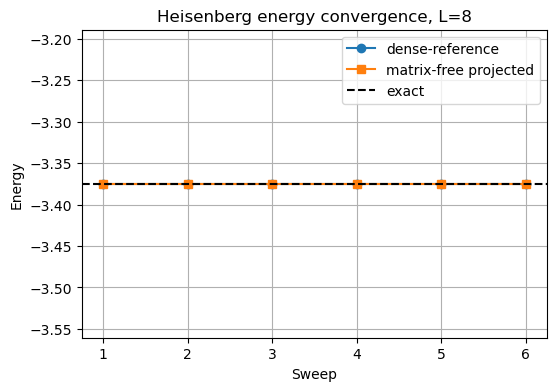

Saved: figureAKLT\heisenberg_energy_convergence_compare.png


<Figure size 600x400 with 0 Axes>

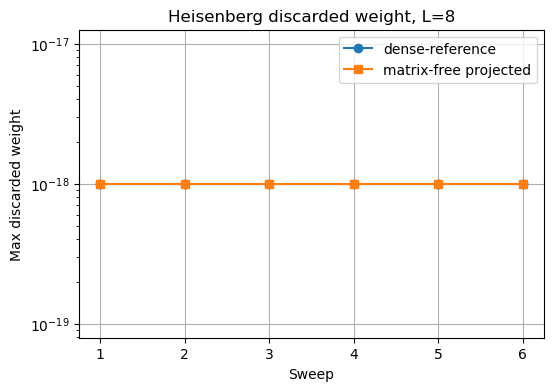

Saved: figureAKLT\heisenberg_discarded_weight_compare.png


<Figure size 600x400 with 0 Axes>

In [20]:
plt.figure()
plt.plot(np.arange(1, len(Ehist_h_ref)+1), Ehist_h_ref, marker='o', label='dense-reference')
plt.plot(np.arange(1, len(Ehist_h_mf)+1), Ehist_h_mf, marker='s', label='matrix-free projected')
plt.axhline(Eexact_h, color='k', linestyle='--', label='exact')
plt.xlabel('Sweep')
plt.ylabel('Energy')
plt.title(f'Heisenberg energy convergence, L={Lh}')
plt.legend()
plt.show()
savefig("heisenberg_energy_convergence_compare.png")
plt.figure()
plt.semilogy(np.arange(1, len(disc_h_ref)+1), np.maximum(disc_h_ref, 1e-18), marker='o', label='dense-reference')
plt.semilogy(np.arange(1, len(disc_h_mf)+1), np.maximum(disc_h_mf, 1e-18), marker='s', label='matrix-free projected')
plt.xlabel('Sweep')
plt.ylabel('Max discarded weight')
plt.title(f'Heisenberg discarded weight, L={Lh}')
plt.legend()
plt.show()
savefig("heisenberg_discarded_weight_compare.png")

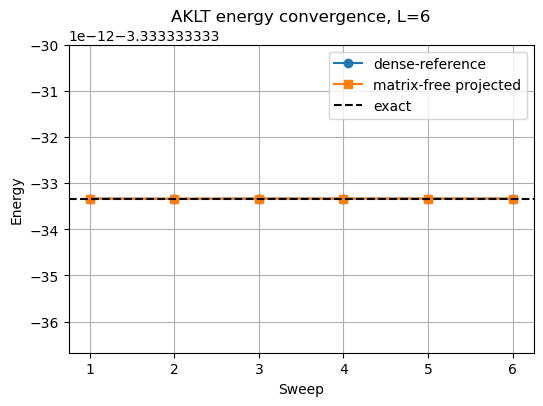

Saved: figureAKLT\aklt_energy_convergence_compare.png


<Figure size 600x400 with 0 Axes>

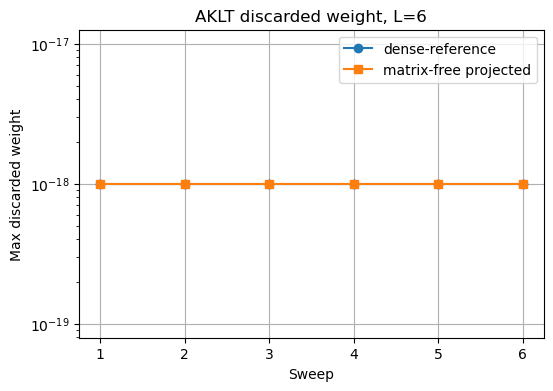

Saved: figureAKLT\aklt_discarded_weight_compare.png


<Figure size 600x400 with 0 Axes>

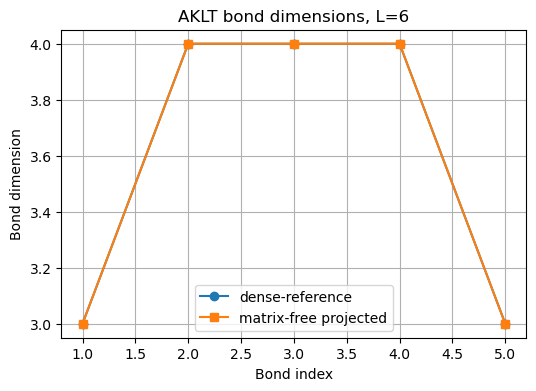

Saved: figureAKLT\aklt_bond_dimensions_compare.png


<Figure size 600x400 with 0 Axes>

In [21]:
plt.figure()
plt.plot(np.arange(1, len(Ehist_a_ref)+1), Ehist_a_ref, marker='o', label='dense-reference')
plt.plot(np.arange(1, len(Ehist_a_mf)+1), Ehist_a_mf, marker='s', label='matrix-free projected')
plt.axhline(Eexact_a, color='k', linestyle='--', label='exact')
plt.xlabel('Sweep')
plt.ylabel('Energy')
plt.title(f'AKLT energy convergence, L={La}')
plt.legend()
plt.show()
savefig("aklt_energy_convergence_compare.png")
plt.figure()
plt.semilogy(np.arange(1, len(disc_a_ref)+1), np.maximum(disc_a_ref, 1e-18), marker='o', label='dense-reference')
plt.semilogy(np.arange(1, len(disc_a_mf)+1), np.maximum(disc_a_mf, 1e-18), marker='s', label='matrix-free projected')
plt.xlabel('Sweep')
plt.ylabel('Max discarded weight')
plt.title(f'AKLT discarded weight, L={La}')
plt.legend()
plt.show()
savefig("aklt_discarded_weight_compare.png")
plt.figure()
plt.plot(range(1, La), mps_bond_dims(mps_a_ref), marker='o', label='dense-reference')
plt.plot(range(1, La), mps_bond_dims(mps_a_mf), marker='s', label='matrix-free projected')
plt.xlabel('Bond index')
plt.ylabel('Bond dimension')
plt.title(f'AKLT bond dimensions, L={La}')
plt.legend()
plt.show()
savefig("aklt_bond_dimensions_compare.png")